# Citation Network Analysis with Author Influence
Fariha Adil, 2375026

## About
The goal of this analysis is to build a citation network to identify influential papers and authors. Graph-based metrics like PageRank and in-degree centrality are used to measure influence, which is then tracked over time to reveal how impact evolves and which papers represent true breakthroughs in computer science research.

## Tasks
- Build a directed citation network where nodes are papers and edges represent citation relationships
- Use graph metrics (in-degree centrality and PageRank) to identify influential papers and authors
- Combine influence scores with temporal data to track how author and paper impact evolves over time
- Identify breakthrough papers that shifted research directions using citation velocity and PageRank

## Motivations
- Understand which papers and authors have truly shaped computer science research beyond simple citation counts
- Identify emerging researchers and paradigm-shifting work that may go unnoticed by raw citation metrics alone
- Track how influence evolves: does an author's impact grow over time or fade? Do seminal papers maintain relevance?
- Discover research momentum: which areas are gaining traction vs. declining

## Challenges
- Computational complexity: building and analyzing networks with millions of nodes and edges requires efficient graph algorithms and working with filtered subsets
- Incomplete citation data: not all papers cite all prior relevant work; citations reflect only the subset recorded in DBLP
- Temporal dynamics: influence changes over time; time windows must be carefully defined and papers with delayed impact must be accounted for
- Bias in metrics: PageRank and centrality favor well-established papers; must balance with novelty metrics like citation velocity
- Author disambiguation: the same name can refer to different authors, making author-level influence aggregation imprecise

In [130]:
"""Import Dependencies"""
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
from collections import defaultdict

In [102]:
"""Globals/Constants"""
SAMPLE_SIZE = 200000
RANDOM_STATE = 42

START_YEAR = 2000
END_YEAR = 2017

In [103]:
"""Load Data"""
cleaned = pd.read_pickle('cleaned_dataset.pkl')

In [104]:
"""Sample for Graph Analysis"""
if SAMPLE_SIZE is not None and len(cleaned) > SAMPLE_SIZE:
    sample = cleaned.sample(n = SAMPLE_SIZE, random_state = RANDOM_STATE).copy()
else:
    sample = cleaned.copy()

print(f"Working sample size: {len(sample):,}")

Working sample size: 200,000


In [105]:
"""Build Citation Network"""
paper_ids = set(sample['id'])

citation_graph = nx.DiGraph()
citation_graph.add_nodes_from(sample['id'])

for paper in sample.itertuples():
    for ref_id in paper.references:
        if ref_id in paper_ids:
            citation_graph.add_edge(paper.id, ref_id)

print(f"Nodes: {citation_graph.number_of_nodes():,}")
print(f"Edges: {citation_graph.number_of_edges():,}")
print(f"Is DAG: {nx.is_directed_acyclic_graph(citation_graph)}")

Nodes: 200,000
Edges: 106,762
Is DAG: False


In [106]:
"""Graph Metrics: In-Degree Centrality and PageRank"""
in_degree = dict(citation_graph.in_degree())
pagerank = nx.pagerank(citation_graph, alpha = 0.85)
id_to_info = sample.set_index('id')[['title', 'year', 'venue', 'n_citation']].to_dict('index')

rows = []
for paper_id, pr_score in pagerank.items():
    info = id_to_info.get(paper_id, {})
    rows.append(
        {'id': paper_id, 
         'title': info.get('title', ''), 
         'year': info.get('year', ''), 
         'venue': info.get('venue', ''), 
         'n_citation': info.get('n_citation', 0), 
         'in_degree': in_degree.get(paper_id, 0), 
         'pagerank': pr_score}
    )

metrics_df = pd.DataFrame(rows)
top_papers = metrics_df.sort_values('pagerank', ascending = False).head(20).reset_index(drop = True)
top_papers

,id,title,year,venue,n_citation,in_degree,pagerank
0,50dd56db-151d-4d62-8576-65f0ef6f381b,Support-Vector Networks,1995,Machine Learning,26114,459,0.001421
1,f14df1ed-e3e9-4348-9040-fc06e3411b95,"Pastry: Scalable, Decentralized Object Locatio...",2001,Lecture Notes in Computer Science,10467,265,0.000880
2,b68fc787-7817-421e-8e66-8a98ab9db1ad,Handbook of Applied Cryptography,1996,,18201,235,0.000816
3,c061069f-29d1-46d4-9974-dede8d5461f9,Genetic programming: on the programming of com...,1992,,15096,256,0.000749
4,510eec1d-f82c-4b19-b116-b8fd4c66531a,Computational geometry: an introduction,1985,Mathematics of Computation,2862,189,0.000707
5,74e3fd8b-f955-4fde-aad8-0a705f05e27e,The temporal logic of programs,1977,foundations of computer science,3545,129,0.000633
6,9849d9c4-a97f-452f-882c-42a8c6cab0b5,A Temporal Logic of Nested Calls and Returns,2004,tools and algorithms for construction and anal...,3137,229,0.000603
7,b592576f-ff29-4a68-9b2f-8a8ad02e9c70,Shape matching and object recognition using sh...,2002,IEEE Transactions on Pattern Analysis and Mach...,6365,197,0.000585
8,1545dfd3-2c25-4ff1-b43c-df4a2a501d06,GPSR: greedy perimeter stateless routing for w...,2000,acm ieee international conference on mobile co...,8821,202,0.000574
9,0ddbfee1-8cc2-49f6-be79-59276f496884,"Independent component analysis, a new concept?",1994,Signal Processing,9460,150,0.000570


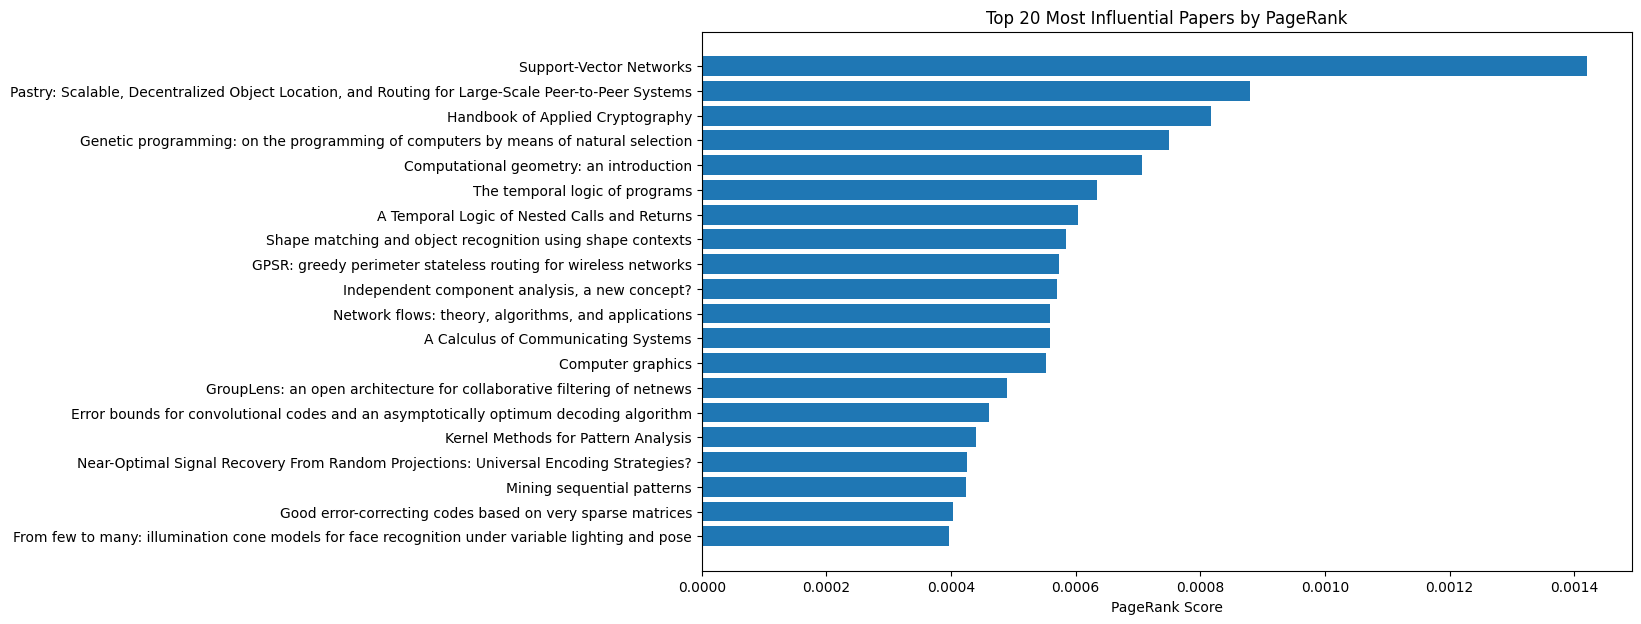

In [140]:
"""Plot Top Papers by Pagerank"""
plt.figure(figsize = (12, 7))
plt.barh(top_papers['title'][::-1], top_papers['pagerank'][::-1])
plt.xlabel('PageRank Score')
plt.title('Top 20 Most Influential Papers by PageRank')
plt.savefig('figures/Top Papers by PageRank.png', bbox_inches = 'tight')
plt.show()

In [108]:
"""Aggregating Influence by Author"""
author_scores = defaultdict(float)
author_paper_count = defaultdict(int)

for paper in sample.itertuples():
    pr = pagerank.get(paper.id, 0)
    for author in paper.authors:
        if author:
            author_scores[author] += pr
            author_paper_count[author] += 1

author_df = pd.DataFrame(
    [{'author': author, 
      'total_pagerank': score, 
      'paper_count': author_paper_count[author], 
      'avg_pagerank': score / author_paper_count[author]} 
      for author, score in author_scores.items()
    ]
)
top_authors = author_df.sort_values('total_pagerank', ascending = False).head(20).reset_index(drop = True)
top_authors

,author,total_pagerank,paper_count,avg_pagerank
0,vladimir vapnik,0.001441,5,0.000288
1,corinna cortes,0.001429,3,0.000476
2,jitendra malik,0.001104,19,0.000058
3,peter druschel,0.001037,10,0.000104
4,antony i. t. rowstron,0.000995,7,0.000142
5,alfred menezes,0.000945,11,0.000086
6,scott a. vanstone,0.000904,6,0.000151
7,amir pnueli,0.000901,19,0.000047
8,serge j. belongie,0.000875,10,0.000088
9,anil k. jain,0.000873,40,0.000022


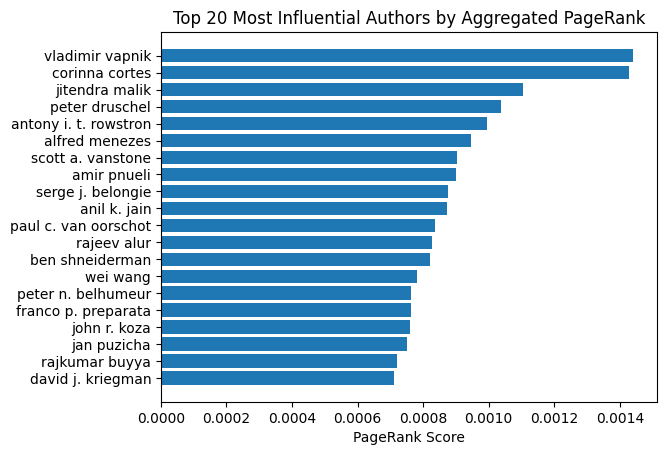

In [137]:
"""Plot Top Authors by Influence"""
plt.barh(top_authors['author'][::-1], top_authors['total_pagerank'][::-1])
plt.xlabel('PageRank Score')
plt.title('Top 20 Most Influential Authors by Aggregated PageRank')
plt.savefig('figures/Top Authors by Influence.png', bbox_inches = 'tight')
plt.show()

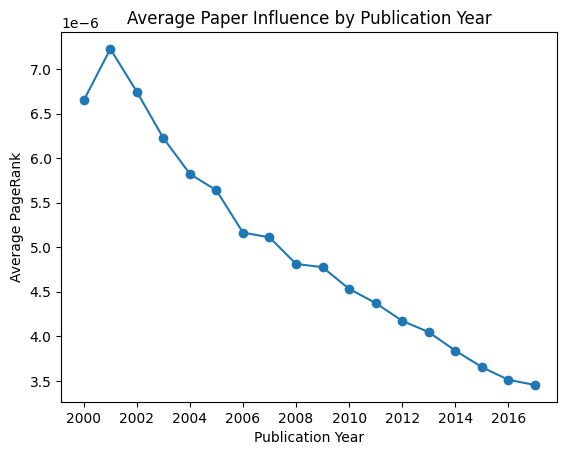

In [138]:
"""Temporal Analysis: Influence by Publication Year"""
yearly_pagerank = (metrics_df.groupby('year')['pagerank'].mean().reset_index().rename(columns = {'pagerank': 'avg_pagerank'}))
yearly_pagerank = yearly_pagerank[(yearly_pagerank['year'] >= START_YEAR) & (yearly_pagerank['year'] <= END_YEAR)]

plt.plot(yearly_pagerank['year'], yearly_pagerank['avg_pagerank'], marker = 'o')
plt.xlabel('Publication Year')
plt.ylabel('Average PageRank')
plt.title('Average Paper Influence by Publication Year')
plt.xticks(range(START_YEAR, END_YEAR + 1, 2))
plt.savefig('figures/Average Influence by Publication Year.png', bbox_inches = 'tight')
plt.show()

In [ ]:
"""Identify Breakthrough Papers"""
metrics_df['years_since_pub'] = 2018 - metrics_df['year']
metrics_df['citation_velocity'] = metrics_df.apply(lambda row: row['n_citation'] / row['years_since_pub'] if row['years_since_pub'] > 0 else 0, axis = 1)

pr_threshold = metrics_df['pagerank'].quantile(0.9)
cv_threshold = metrics_df['citation_velocity'].quantile(0.9)

breakthrough = metrics_df[(metrics_df['pagerank'] >= pr_threshold) & (metrics_df['citation_velocity'] >= cv_threshold)].sort_values('citation_velocity', ascending = False).head(15).reset_index(drop = True)
breakthrough[['title', 'year', 'venue', 'n_citation', 'citation_velocity', 'pagerank']]

,title,year,venue,n_citation,citation_velocity,pagerank
0,MRBAYES: Bayesian inference of phylogenetic trees,2001,Bioinformatics,19332,1137.176471,0.000030
1,Support-Vector Networks,1995,Machine Learning,26114,1135.391304,0.001421
2,MEGA3: Integrated software for Molecular Evolu...,2004,Briefings in Bioinformatics,13783,984.500000,0.000006
3,RAxML-VI-HPC: maximum likelihood-based phyloge...,2006,Bioinformatics,11314,942.833333,0.000045
4,Handbook of Applied Cryptography,1996,,18201,827.318182,0.000816
5,TopHat: discovering splice junctions with RNA-Seq,2009,Bioinformatics,7290,810.000000,0.000068
6,MEGA2: molecular evolutionary genetics analysi...,2001,Bioinformatics,11264,662.588235,0.000011
7,Cloud computing and emerging IT platforms: Vis...,2009,Future Generation Computer Systems,5912,656.888889,0.000328
8,"Pastry: Scalable, Decentralized Object Locatio...",2001,Lecture Notes in Computer Science,10467,615.705882,0.000880
9,Power-Law Distributions in Empirical Data,2009,Siam Review,5331,592.333333,0.000212


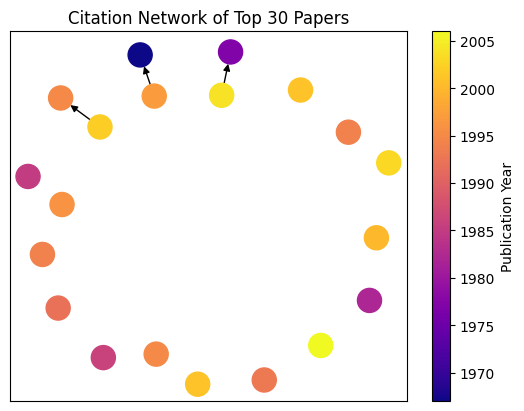

In [139]:
"""Visualize Citation Network of Top 30 Papers"""
top_ids = set(top_papers['id'].head(30))
subgraph = citation_graph.subgraph(top_ids)

year_map = sample.set_index('id')['year'].to_dict()
node_years = [year_map.get(node, START_YEAR) for node in subgraph.nodes()]

pos = nx.spring_layout(subgraph, seed = RANDOM_STATE)
nx.draw_networkx_edges(subgraph, pos, arrows = True)
sc = nx.draw_networkx_nodes(subgraph, pos, node_color = node_years, cmap = plt.cm.plasma)
plt.colorbar(sc, label = 'Publication Year')
plt.title('Citation Network of Top 30 Papers')
plt.savefig('figures/Citation Network of Top 30 Papers.png', bbox_inches = 'tight')
plt.show()


In [ ]:
"""Save Outputs"""
os.makedirs('outputs', exist_ok = True)
top_papers.to_csv('outputs/top_papers_by_pagerank.csv', index = False)
top_authors.to_csv('outputs/top_authors_by_influence.csv', index = False)
breakthrough.to_csv('outputs/breakthrough_papers.csv', index = False)
yearly_pagerank.to_csv('outputs/influence_by_year.csv', index = False)